In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.interpolate import UnivariateSpline

In [2]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.50_chi1=0.60_chi2=0.70_th1=45_th2=45_dphi=90.csv'

In [ ]:
# Read the initial setup (mass ratio and spins) from the header, then load the evolution data.
# Calculate the total mass by including the 0PN binding energy, and find the total angular momentum by combining the 0PN orbital momentum and spin vectors.

with open(file_path, 'r') as f:
    f.readline() 
    header_line = f.readline() 

q = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))

df = pd.read_csv(file_path, comment='#')
a = df['separation_M']
th1 = df['theta1_rad']
th2 = df['theta2_rad']
dphi = df['deltaphi_rad']

m1 = 1 / (1 + q)
m2 = q / (1 + q)
eta = m1 * m2 

E_binding = (m1 * m2) / (2 * a)
M_tot = m1 + m2 - np.abs(E_binding)


S1 = chi1 * m1**2
S2 = chi2 * m2**2

L_0PN = eta * np.sqrt(a)

L_dot_S1 = L_0PN * S1 * np.cos(th1)
L_dot_S2 = L_0PN * S2 * np.cos(th2)
S1_dot_S2 = S1 * S2 * (np.sin(th1) * np.sin(th2) * np.cos(dphi) + 
                       np.cos(th1) * np.cos(th2))

J_tot = np.sqrt(L_0PN**2 + S1**2 + S2**2 + 2*L_dot_S1 + 2*L_dot_S2 + 2*S1_dot_S2)

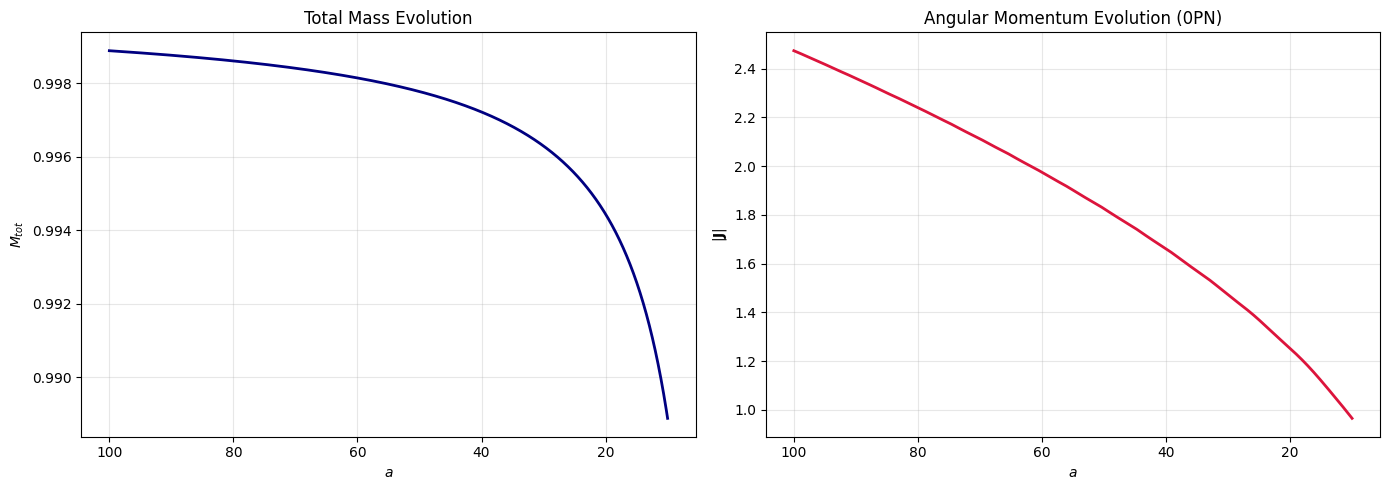

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Total Mass
ax[0].plot(a, M_tot, color='navy', lw=2)
ax[0].set_xlabel('$a$')
ax[0].set_ylabel('$M_{tot}$')
ax[0].set_title('Total Mass Evolution')
ax[0].grid(True, alpha=0.3)
ax[0].invert_xaxis() 

# Total Angular Momentum
ax[1].plot(a, J_tot, color='crimson', lw=2)
ax[1].set_xlabel('$a$')
ax[1].set_ylabel(r'$|\mathbf{J}|$')
ax[1].set_title('Angular Momentum Evolution (0PN)')
ax[1].grid(True, alpha=0.3)
ax[1].invert_xaxis()

plt.tight_layout()
plt.show()

In [5]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

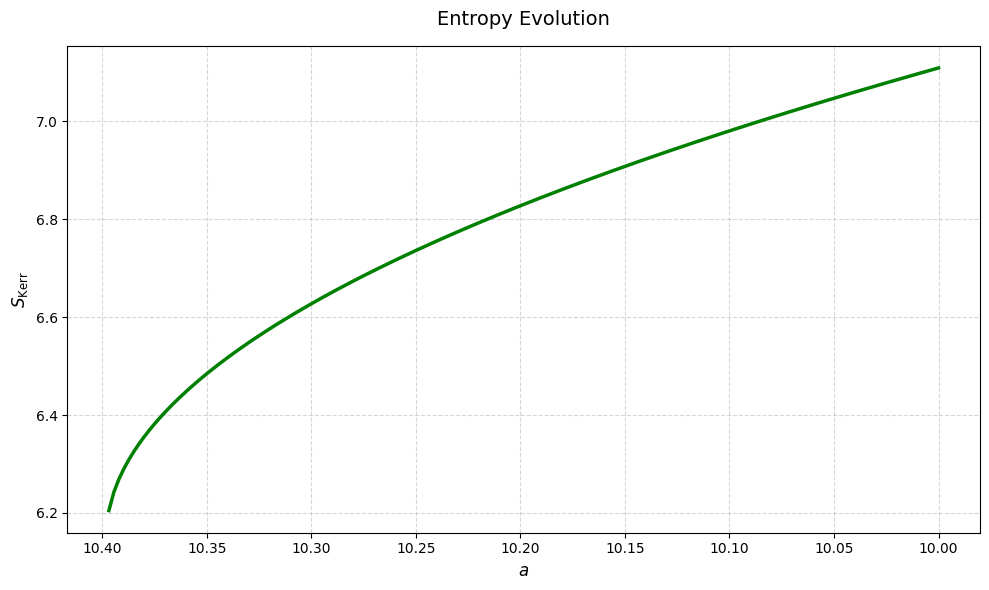

In [6]:
ENT = entropy (M_tot, J_tot)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(a, ENT, color='green', lw=2.5)

ax.set_xlabel('$a$', fontsize=12)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontsize=12)
ax.set_title('Entropy Evolution', fontsize=14, pad=15)
ax.invert_xaxis()
ax.grid(True, linestyle='--', alpha=0.5) 
plt.tight_layout()
plt.show()

In [9]:
# Clean up the data, sort it, and use a 4th-degree polynomial to fit the mass and angular momentum based on the physical velocity parameter (1/sqrt(a)).
# Extrapolate those fits toward the merger to calculate the theoretical entropy, and pinpoint its maximum.

valid_mask = ~np.isnan(ENT)

valid_mask = ~np.isnan(ENT)
a_valid = np.array(a)[valid_mask]
M_tot_valid = np.array(M_tot)[valid_mask]
J_tot_valid = np.array(J_tot)[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_tot_valid[sort_idx]
J_fit = J_tot_valid[sort_idx]


x_fit = 1.0 / np.sqrt(a_fit)
degree = 4 


poly_M = np.poly1d(np.polyfit(x_fit, M_fit, degree))
poly_J = np.poly1d(np.polyfit(x_fit, J_fit, degree))


a_extrap = np.linspace(min(a_fit), 3.0, 1000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = poly_M(x_extrap)
J_extrap = poly_J(x_extrap)


ENT_extrap = entropy(M_extrap, J_extrap)


idx_max = np.nanargmax(ENT_extrap)
a_max_entropy = a_extrap[idx_max]
S_max_entropy = ENT_extrap[idx_max]

print(f"Maximum found at a = {a_max_entropy:.3f}")

Maximum found at a = 5.915


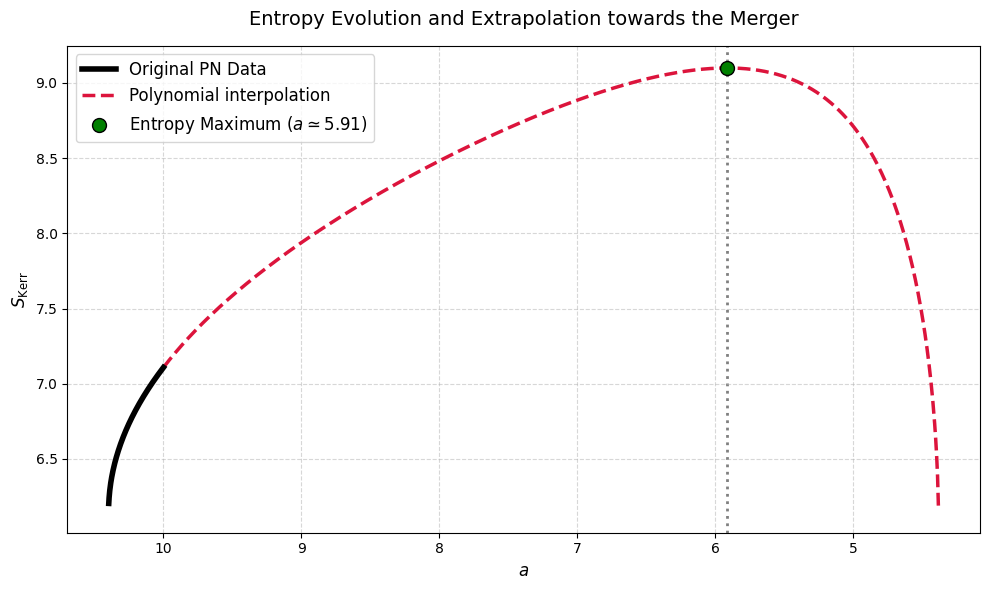

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ENT_valid_sorted = np.array(ENT)[valid_mask][sort_idx]
ax.plot(a_fit, ENT_valid_sorted, color='black', lw=4, zorder=3,
        label='Original PN Data')

ax.plot(a_extrap, ENT_extrap, color='crimson', lw=2.5, linestyle='--', zorder=2,
        label='Polynomial interpolation')

ax.scatter([a_max_entropy], [S_max_entropy], color='green', edgecolor='black', s=100, zorder=4,
           label=f'Entropy Maximum ($a \\simeq {a_max_entropy:.2f}$)')
ax.axvline(a_max_entropy, color='gray', linestyle=':', lw=2, zorder=1)
ax.set_xlabel('$a$', fontsize=12)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontsize=12)
ax.set_title('Entropy Evolution and Extrapolation towards the Merger', fontsize=14, pad=15)
ax.invert_xaxis()
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.show()